# Crohn's Disease Microbiome — Exploratory Data Analysis

**Project:** crohns-microbiome-ml  
**Dataset:** HMP2 / iHMP (Human Microbiome Project 2 — IBD cohort)  
**Goal:** Explore the OTU abundance table and metadata to understand the dataset before modeling.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import skbio as skbio
import scipy as scipy
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler 
import umap 

print('Libraries loaded successfully!')

In [ ]:
metadata = pd.read_csv('/Users/liamcampbell/Desktop/crohns-microbiome-ml/data/hmp2_metadata_2018-08-20.csv', low_memory=False)
otuTable = pd.read_csv('/Users/liamcampbell/Desktop/crohns-microbiome-ml/data/taxonomic_profiles.tsv.gz', sep= '\t', index_col=0)


print(metadata.shape, otuTable.shape)

meta_16S = metadata[metadata['data_type'].str.contains('16S', na=False)]
print(meta_16S['diagnosis'].value_counts())

print('CD = Crohns Disease')
print('UC = Ulcerative Colitis')
print('nonIBD = Healthy Controls')


(5533, 490) (982, 179)
diagnosis
CD        211
UC         89
nonIBD     58
Name: count, dtype: int64
CD = Crohns Disease
UC = Ulcerative Colitis
nonIBD = Healthy Controls


In [ ]:
# Join OTU table with diagnosis labels
# OTU table: rows=taxa, cols=samples — transpose so rows=samples
otu_t = otuTable.T  # now (179, 982)
otu_t.index.name = 'External ID'

# Join on External ID
meta_16s = metadata[metadata['data_type'].str.contains('16S', na=False)]
otu_meta = otu_t.join(meta_16s.set_index('External ID')[['diagnosis', 'week_num', 'Participant ID']], how='inner')

print("Joined shape:", otu_meta.shape)
print(otu_meta['diagnosis'].value_counts())

Joined shape: (178, 985)
diagnosis
CD        86
nonIBD    46
UC        46
Name: count, dtype: int64


In [ ]:
# Q1: Samples per group
print("Total samples:", len(otu_meta))
print(otu_meta['diagnosis'].value_counts())

# Q2: Number of bacterial taxa
n_taxa = otuTable.shape[0]
print("\nNumber of taxa:", n_taxa)

# Q3: Sparsity (% zeros)
otu_only = otu_meta.iloc[:, :982]  # just the OTU columns
sparsity = (otu_only == 0).sum().sum() / otu_only.size * 100
print(f"\nSparsity: {sparsity:.1f}% zeros")

# Q4: Top 10 most abundant taxa
top10 = otu_only.sum().sort_values(ascending=False).head(10)
print("\nTop 10 taxa:\n", top10)

# Q5: Samples with very few reads (potential quality issues)
read_counts = otu_only.sum(axis=1)
print("\nRead counts per sample:")
print(read_counts.describe())
low_quality = read_counts[read_counts < read_counts.quantile(0.05)]
print(f"\nPotential low-quality samples (<5th percentile): {len(low_quality)}")

Total samples: 178
diagnosis
CD        86
nonIBD    46
UC        46
Name: count, dtype: int64

Number of taxa: 982

Sparsity: 91.7% zeros

Top 10 taxa:
 Unc05bd1    436194.0
Unc64172    409198.0
Unc054vi    294448.0
Unc91005    111388.0
UncG3786    109438.0
UncO8895     75291.0
Unc01pk4     47133.0
Unc00y95     46903.0
UncC1868     44063.0
Unc69508     41982.0
dtype: object

Read counts per sample:
count       178.0
unique      178.0
top       23607.0
freq          1.0
dtype: float64

Potential low-quality samples (<5th percentile): 9


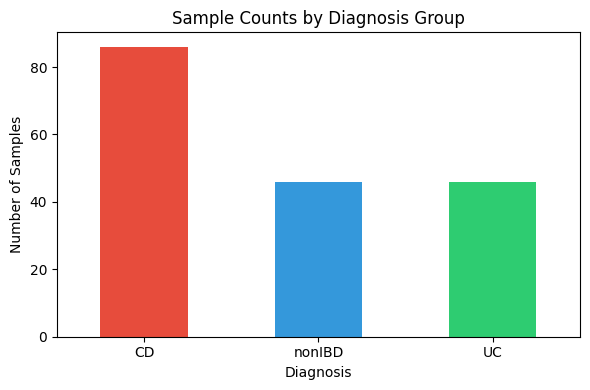

In [ ]:
# Bar chart of sample counts by diagnosis
fig, ax = plt.subplots(figsize=(6, 4))
otu_meta['diagnosis'].value_counts().plot(kind='bar', ax=ax, color=['#e74c3c','#3498db','#2ecc71'])
ax.set_title('Sample Counts by Diagnosis Group')
ax.set_xlabel('Diagnosis')
ax.set_ylabel('Number of Samples')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig('../figures/sample_counts_by_diagnosis.png', dpi=150)
plt.show()

---
## Why Microbiome Data is Weird: Compositional Data & CLR

### The problem: abundances are relative, not absolute

In a standard OTU table, each row / sample contains read **counts** for hundreds of bacterial taxa. But here's the catch: **the total number of reads per sample is an artifact of sequencing depth, not biology.** If sample A has 10,000 reads and sample B has 50,000 reads, we can't directly compare the raw counts between them.

The standard fix is to **normalize** — convert counts to proportions (each taxon's share of the total). But this creates a new problem: the data is now **compositional**. All proportions in a sample sum to 1, which means:

- If one taxon increases, all others must mathematically decrease (even if their absolute abundance didn't change)
- Standard statistics assume features are independent — compositional data violates this
- Distances and correlations calculated on raw proportions are systematically distorted

### The fix: CLR (Centered Log-Ratio) transformation

The CLR transformation removes the constraint that values must sum to 1 by expressing each taxon's abundance *relative to the geometric mean of all taxa in that sample*:

```
CLR(x_i) = log(x_i / geometric_mean(x))
```

CLR tells you whether a given bacterium is more or less abundant than the "average" bacterium in that sample — in log scale. This makes the data symmetric around zero and suitable for standard ML algorithms.

CLR transforms relative abundances into log-ratios against the sample's geometric mean, breaking the sum-to-one constraint so that standard ML algorithms work correctly on microbiome data.

> **Zero problem:** Microbiome data is ~92% zeros (we saw this in Day 3). Since log(0) = -∞, we add a small **pseudocount** (0.5) before transforming — a standard practice.

In [ ]:
from scipy.stats import gmean

def clr_transform(df):
    """
    Centered Log-Ratio (CLR) transformation for compositional microbiome data.
    
    Steps:
      1. Add pseudocount of 0.5 to handle zeros (log(0) is undefined)
      2. Take natural log of each value
      3. Subtract each sample's log-geometric-mean (= mean of log values)
    
    Result: each value represents how much more/less abundant a taxon is
    compared to the geometric mean of all taxa in that sample.
    
    Args:
        df: DataFrame with shape (samples, taxa) — rows are samples
    Returns:
        DataFrame of same shape with CLR-transformed values
    """
    df_pseudo = df + 0.5          # pseudocount to avoid log(0)
    log_df = np.log(df_pseudo)    # natural log
    geometric_mean = log_df.mean(axis=1)  # mean of logs = log of geometric mean
    return log_df.subtract(geometric_mean, axis=0)


# Extract just the OTU columns (everything except diagnosis, week_num, Participant ID)
meta_cols = ['diagnosis', 'week_num', 'Participant ID']
otu_cols = [c for c in otu_meta.columns if c not in meta_cols]
otu_only = otu_meta[otu_cols].astype(float)

# Apply CLR
otu_clr = clr_transform(otu_only)

print("Original OTU table (first 3 samples, first 5 taxa):")
print(otu_only.iloc[:3, :5].to_string())
print()
print("After CLR transformation:")
print(otu_clr.iloc[:3, :5].to_string())
print()
print(f"CLR shape: {otu_clr.shape}")
print(f"CLR value range: [{otu_clr.values.min():.2f}, {otu_clr.values.max():.2f}]")
print(f"CLR row means: {otu_clr.mean(axis=1).head(3).values.round(6)}")
print()
print("✓ CLR transform ready — this will be the feature matrix for all ML models.")

NameError: name 'otu_meta' is not defined

Highly abundant taxa become positive so the taxa with value 0.553439 is 
one with abundant taxa. 

We are looking at "how unusual is this taxon relative to this sample's average"

Range of $[-0.72, 10.45]$ is to be expected as negative end is near-zero taxa, and the positive end is the handful of dominant taxa that are high above sample's geometric mean.

By definition, CLR centers each sample / row around zero, so the mean of all CLR values in a row / sample must be zero (which it is). 

In [ ]:
# --- What does the OTU table actually look like? ---

# 1. Shape reminder
print(f"OTU table shape: {otu_only.shape}  →  (samples × taxa)")
print()

# 2. A readable slice: first 5 samples, first 8 taxa
print("Raw counts — first 5 samples, first 8 taxa:")
display(otu_only.iloc[:5, :8])

# 3. Same slice after CLR
print("After CLR — same 5 samples, first 8 taxa:")
display(otu_clr.iloc[:5, :8].round(3))

# 4. The most abundant taxa (easier to read than random columns)
print("Top 5 most abundant taxa across all samples:")
top5_cols = otu_only.sum().sort_values(ascending=False).head(5).index.tolist()
display(otu_only[top5_cols].head(5))

# 5. Tip: in JupyterLab you can also just run:
#    otu_only          → scrollable interactive table
#    otu_only.head(20) → first 20 rows
#    otu_only.describe() → summary stats for every column
print()
print("Tip: run `otu_only` alone in a cell for a scrollable interactive table in JupyterLab.")

OTU table shape: (178, 982)  →  (samples × taxa)

Raw counts — first 5 samples, first 8 taxa:


,IP8BSoli,UncTepi3,Unc004ii,Unc00re8,Unc018j2,Unc04u81,Unc58370,Unc05fip
External ID,,,,,,,,
206646,0.0,0.0,0.0,0.0,1.0,0.0,2.0,0.0
224324,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
206619,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
224326,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
206624,17.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


After CLR — same 5 samples, first 8 taxa:


,IP8BSoli,UncTepi3,Unc004ii,Unc00re8,Unc018j2,Unc04u81,Unc58370,Unc05fip
External ID,,,,,,,,
206646,-0.545,-0.545,-0.545,-0.545,0.553,-0.545,1.064,-0.545
224324,-0.259,-0.259,-0.259,-0.259,-0.259,-0.259,-0.259,-0.259
206619,-0.100,-0.100,-0.100,-0.100,-0.100,-0.100,-0.100,-0.100
224326,-0.467,-0.467,-0.467,-0.467,-0.467,-0.467,-0.467,-0.467
206624,3.447,-0.109,-0.109,-0.109,-0.109,-0.109,-0.109,-0.109


Top 5 most abundant taxa across all samples:


,Unc05bd1,Unc64172,Unc054vi,Unc91005,UncG3786
External ID,,,,,
206646,1940.0,3845.0,4788.0,165.0,149.0
224324,13904.0,3010.0,186.0,1030.0,1384.0
206619,339.0,0.0,1118.0,3.0,21.0
224326,2783.0,3822.0,1342.0,392.0,1484.0
206624,34.0,25.0,24.0,3.0,33.0



Tip: run `otu_only` alone in a cell for a scrollable interactive table in JupyterLab.


Alpha diversity computed — Shannon diversity calculated per sample, boxplot (CD vs nonIBD) saved, Mann-Whitney p-value reported, biological finding noted (do Crohn's patients have lower diversity?)

Microbiome Metrics - quantitative tools that summarize microbial  composition and structure. 

**Alpha Diversity** - diversity within a single sample.

**Beta Diversity** - diversity between samples.

Together, they describe both the internal complexity of each microbiome and how communities differ across environments, hosts, or treatments.

**Alpha Diversity**

Reflects diversity within single microbial community. It combines:

*Richness* - the number of taxa detected (species, OTUs, or ASVs)
*Evenness* - how evenly those taxa are distributed in abundance.

**High Alpha Diversity** - can indicate ecological stability, resilience, or environmental heterogeneity.

**Low Alpha Diversity** - may signal disturbance, infection, or dominance by a few resilient species. 

**Alpha Diversity Metrics**

1. *Observed Taxa (Richness)* 
    - Counts unique species or ASVs.
    - Simple but ignores evenness
2. *Chao1 Index*
    - Estimates true richness by accounting for rare taxa. 
3. *Shannon Index*
    - Combines richness and evenness
    - Increases as community becomes more balanced
    - Sensitive to moderately abundant species
4. *Simpson Index*
    - Emphasizes dominance by abundant species
    - Often presented as 1 - D (Simpson diversity)
5. *Faith's Phylogenetic Diversity (PD)
    - Considers evolutionary distances among taxa
    - Sums branch lengths in a phylogenetic tree covering observed species
    - Useful when taxonomy is uncertain


Specific Project Info : 
    In human gut microbiome studies, reduced Shannon Diversity is often linked to inflammatory bowel disease (IBD). A lower diversity suggests loss of beneficial taxa and expansion of inflammation-tolerant microbes.


In [ ]:
from scipy.stats import mannwhitneyu

# --- Shannon Diversity per Sample ---
# Shannon index: H = -sum(p_i * log(p_i))
# where p_i is the relative proportion of each taxon in a sample.

def shannon_diversity(row):
    """Compute Shannon entropy (H) for a single sample (row of counts)."""
    counts = row[row > 0]            # drop zeros
    if counts.sum() == 0:
        return 0.0
    proportions = counts / counts.sum()
    return -(proportions * np.log(proportions)).sum()

# Apply to every sample (row) in the raw OTU table
shannon = otu_only.apply(shannon_diversity, axis=1)
shannon.name = 'shannon_H'

# Attach diagnosis labels
shannon_df = shannon.to_frame().join(otu_meta['diagnosis'])

print("Shannon diversity computed for", len(shannon_df), "samples")
print()
print(shannon_df.groupby('diagnosis')['shannon_H'].describe().round(3))

Shannon diversity computed for 178 samples

           count   mean    std    min    25%    50%    75%    max
diagnosis                                                        
CD          86.0  2.440  0.650  0.075  2.039  2.544  2.863  3.503
UC          46.0  2.615  0.602  1.118  2.233  2.555  3.086  3.590
nonIBD      46.0  2.775  0.542  1.604  2.375  2.810  3.122  3.875


/var/folders/9z/qzwb0qz50ml05y5ptvkxby3r0000gn/T/ipykernel_63202/3854200491.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groups, labels=order, patch_artist=True, widths=0.5,


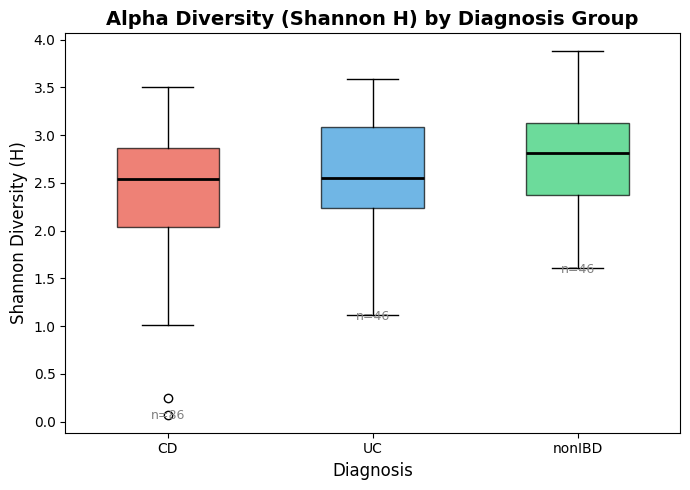

Boxplot saved to figures/shannon_diversity_boxplot.png


In [ ]:
# --- Boxplot: Shannon Diversity by Diagnosis Group ---

fig, ax = plt.subplots(figsize=(7, 5))

order = ['CD', 'UC', 'nonIBD']
colors = {'CD': '#e74c3c', 'UC': '#3498db', 'nonIBD': '#2ecc71'}

groups = [shannon_df[shannon_df['diagnosis'] == d]['shannon_H'] for d in order]

bp = ax.boxplot(groups, labels=order, patch_artist=True, widths=0.5,
                medianprops=dict(color='black', linewidth=2))

for patch, d in zip(bp['boxes'], order):
    patch.set_facecolor(colors[d])
    patch.set_alpha(0.7)

ax.set_title('Alpha Diversity (Shannon H) by Diagnosis Group', fontsize=14, fontweight='bold')
ax.set_xlabel('Diagnosis', fontsize=12)
ax.set_ylabel('Shannon Diversity (H)', fontsize=12)

# Annotate with sample sizes
for i, (d, grp) in enumerate(zip(order, groups), start=1):
    ax.text(i, grp.min() - 0.05, f'n={len(grp)}', ha='center', fontsize=9, color='grey')

plt.tight_layout()
plt.savefig('../figures/shannon_diversity_boxplot.png', dpi=150)
plt.show()
print("Boxplot saved to figures/shannon_diversity_boxplot.png")

In [ ]:
# --- Mann-Whitney U Test: CD vs nonIBD ---
# Non-parametric test — no normality assumption needed (good for microbiome data).

cd_vals = shannon_df[shannon_df['diagnosis'] == 'CD']['shannon_H']
nonibd_vals = shannon_df[shannon_df['diagnosis'] == 'nonIBD']['shannon_H']

stat, p_value = mannwhitneyu(cd_vals, nonibd_vals, alternative='two-sided')

print(f"Mann-Whitney U Test — CD vs nonIBD")
print(f"  U statistic : {stat:.1f}")
print(f"  p-value     : {p_value:.4f}")
print()
if p_value < 0.05:
    cd_med = cd_vals.median()
    nonibd_med = nonibd_vals.median()
    direction = "lower" if cd_med < nonibd_med else "higher"
    print(f"  ✓ Significant (p < 0.05)")
    print(f"  CD median H = {cd_med:.3f}  |  nonIBD median H = {nonibd_med:.3f}")
    print(f"  → Crohn's patients show {direction} alpha diversity than healthy controls.")
else:
    print(f"  ✗ Not significant (p ≥ 0.05) — no strong diversity difference detected.")

Mann-Whitney U Test — CD vs nonIBD
  U statistic : 1414.0
  p-value     : 0.0071

  ✓ Significant (p < 0.05)
  CD median H = 2.544  |  nonIBD median H = 2.810
  → Crohn's patients show lower alpha diversity than healthy controls.


Next, we will calculate the **Beta Diversity** using the **Bray-Curtis Distance Matrix**. 

**Beta Diversity** will show us how similar two samples are to each other. This will help us understand whether Crohn's patients have a consistently different microbial community composition from healthy controls. 

We use **Bray-Curtis** method because it is a standard for microbiome work. It compares two samples based on the abundance of shared species, ranging from 0 (identical) to 1 (nothing in common). 

In [ ]:
bray_curtis_distances = skbio.diversity.beta_diversity("braycurtis", otu_only.values, ids=otu_only.index.tolist())
bray_curtis_dataframe = bray_curtis_distances.to_data_frame()
bray_curtis_dataframe.to_csv('../data/bray_curtis_distances.csv')
print("Bray-Curtis distance matrix saved to data/bray_curtis_distances.csv")

Bray-Curtis distance matrix saved to data/bray_curtis_distances.csv


In [ ]:
bray_curtis_distances_scipy = scipy.spatial.distance.cdist(otu_only.values, otu_only.values, metric='braycurtis')
bray_curtis_dataframe_scipy = pd.DataFrame(bray_curtis_distances_scipy, index=otu_only.index, columns=otu_only.index)
bray_curtis_dataframe_scipy.to_csv('../data/bray_curtis_distances_scipy.csv')
print("Bray-Curtis distance matrix saved to data/bray_curtis_distances_scipy.csv")

Bray-Curtis distance matrix saved to data/bray_curtis_distances_scipy.csv


Now we will use **UMAP** (Uniform Manifold Approximation and Projection) to reduce the matrices dimensions. 

UMAP will take our high-dimensional data and project it onto a low-dimensional space (2D or 3D) for visualization or downstream machine learning. 

In [ ]:
reducer = umap.UMAP()
umap_embedding = reducer.fit_transform(otu_clr.values)
umap_df = pd.DataFrame(umap_embedding, columns=['UMAP1', 'UMAP2'], index=otu_clr.index)
umap_df = umap_df.join(otu_meta['diagnosis'])           
print("UMAP embedding created with shape:", umap_df.shape)

In [ ]:
colors = {'CD': '#e74c3c', 'UC': '#3498db', 'nonIBD': '#2ecc71'}

fig, ax = plt.subplots(figsize=(8, 6), facecolor='white')
ax.set_facecolor('white')

for diagnosis, group in umap_df.groupby('diagnosis'):
    ax.scatter(group['UMAP1'], group['UMAP2'],
               c=colors[diagnosis], label=diagnosis,
               s=40, alpha=0.7, edgecolors='none')

ax.set_title('UMAP Projection of Microbiome Samples', fontsize=14, fontweight='bold')
ax.set_xlabel('UMAP1', fontsize=12)
ax.set_ylabel('UMAP2', fontsize=12)
ax.legend(title='Diagnosis', fontsize=10)
ax.annotate(f'UMAP: n_neighbors=15, min_dist=0.1',
            xy=(0.99, 0.01), xycoords='axes fraction',
            ha='right', va='bottom', fontsize=8, color='grey')

plt.tight_layout()
plt.savefig('../figures/umap_projection.png', dpi=150, facecolor='white')
plt.show()
print("UMAP plot saved to figures/umap_projection.png")